In [1]:
# ============================================================
# LEGAL CLAUSE SIMILARITY ENGINE
# ============================================================
#
# NLP Approach:
#   Word2Vec + TF-IDF Weighted Clause Embeddings
#
# Business Goal:
#   Given a legal clause/sentence/paragraph,
#   retrieve the most semantically similar clauses
#   from a predefined legal document dataset.
#
# Project Lifecycle:
#
#   1. Business Understanding
#   2. Data Collection
#   3. Data Understanding
#   4. Data Preparation
#   5. Model Building
#   6. Model Training
#   7. Model Evaluation
#   8. Model Testing
#   9. Model Saving
#
# Later:
#   The saved model will be moved to VS Code,
#   integrated with FastAPI + Frontend,
#   and deployed to Render.
# ============================================================

print("Legal Clause Similarity Engine")
print("NLP Model: Word2Vec")
print("Task: Semantic Similarity / Semantic Search")
print("Environment: Google Colab")

Legal Clause Similarity Engine
NLP Model: Word2Vec
Task: Semantic Similarity / Semantic Search
Environment: Google Colab


## 1. Business Understanding

In [ ]:
# ============================================================
# STEP 1: BUSINESS UNDERSTANDING
# ============================================================
#
# Business Problem:
#
# Legal teams work with large numbers of:
#   - Contracts
#   - Agreements
#   - Policy documents
#   - Legal clauses
#
# Finding clauses with similar meaning manually can be
# time-consuming.
#
# Example:
#
# Input clause:
# "The receiving party shall keep confidential information
#  secret and shall not disclose it to any third party."
#
# Another document might contain:
#
# "Each party must protect sensitive information received
#  from the other party and must not make it available
#  to external persons."
#
# The words are different, but the meaning is similar.
#
# Therefore, keyword matching alone is not sufficient.
#
# Our objective:
#
#       TEXT
#        ↓
#   Semantic Representation
#        ↓
#   Similarity Calculation
#        ↓
#   Ranked Similar Clauses
# ============================================================

business_problem = """
Legal and compliance teams need to find clauses with similar
meaning across large collections of legal documents.

The system should retrieve semantically similar clauses even
when the wording is different.
"""

objective = """
Given a legal clause, sentence, or short paragraph,
return a ranked list of the most semantically similar
clauses from the dataset.
"""

print("BUSINESS PROBLEM")
print(business_problem)

print("\nOBJECTIVE")
print(objective)

BUSINESS PROBLEM

Legal and compliance teams need to find clauses with similar
meaning across large collections of legal documents.

The system should retrieve semantically similar clauses even
when the wording is different.


OBJECTIVE

Given a legal clause, sentence, or short paragraph,
return a ranked list of the most semantically similar
clauses from the dataset.



## 2. Install Libraries

In [3]:
# ============================================================
# STEP 2: INSTALL REQUIRED LIBRARIES
# ============================================================
#
# Google Colab already provides many Python libraries.
# However, we explicitly install the versions/components
# required for this project so that the environment is
# reproducible.
#
# gensim:
#   Used to train the Word2Vec NLP model.
#
# scikit-learn:
#   Used for:
#       - Train/test splitting
#       - TF-IDF
#       - Evaluation utilities
#
# joblib:
#   Used later to save our trained model artifacts.
# ============================================================

!pip install -q gensim scikit-learn pandas numpy joblib matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 45.5 MB/s eta 0:00:00


## 3. Import Libraries

In [20]:
# ============================================================
# STEP 3: IMPORT LIBRARIES
# ============================================================
#
# We import everything required for the complete ML workflow.
#
# We are intentionally importing the libraries in logical
# groups so that you can understand their responsibility.
# ============================================================

# -----------------------------
# Python Standard Libraries
# -----------------------------

import os
import re
import json
import warnings

# Suppress unnecessary warning messages during experimentation.
warnings.filterwarnings("ignore")


# -----------------------------
# Data Handling
# -----------------------------

import pandas as pd
import numpy as np


# -----------------------------
# Visualization
# -----------------------------

import matplotlib.pyplot as plt


# -----------------------------
# Word2Vec
# -----------------------------

from gensim.models import Word2Vec


# -----------------------------
# Scikit-learn
# -----------------------------

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import normalize

from sklearn.metrics import accuracy_score

from sklearn.model_selection import train_test_split


# -----------------------------
# Model Saving
# -----------------------------

import joblib


# -----------------------------
# Display Configuration
# -----------------------------

pd.set_option("display.max_colwidth", 200)

print("All required libraries imported successfully.")

All required libraries imported successfully.


## 4. Upload Dataset

In [5]:
# ============================================================
# STEP 4: UPLOAD DATASET
# ============================================================
#
# Google Colab runs in a temporary cloud environment.
# Therefore, our local CSV file must be uploaded into
# the Colab runtime.
#
# We will upload:
#
#       legal_docs.csv
#
# After uploading, Colab will make the file available
# inside the current working directory.
# ============================================================

from google.colab import files

uploaded = files.upload()

print("\nUploaded files:")
for filename in uploaded.keys():
    print(" -", filename)

Saving legal_docs.csv to legal_docs.csv

Uploaded files:
 - legal_docs.csv


## 5. Load the Dataset

In [6]:
# ============================================================
# STEP 5: LOAD DATASET
# ============================================================
#
# pandas.read_csv() loads the CSV file into a DataFrame.
#
# A DataFrame is essentially a table in Python.
#
# Example:
#
#       clause_text                  clause_type
#       ----------------------------------------
#       "The buyer shall..."         payment
#       "The party shall..."         confidentiality
#
# ============================================================

# Find the uploaded CSV file automatically.
csv_files = [filename for filename in uploaded.keys()
             if filename.lower().endswith(".csv")]

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV file was uploaded. Please upload legal_docs.csv."
    )

# We expect one primary CSV for this project.
DATA_FILE = csv_files[0]

# Load the CSV into a pandas DataFrame.
df = pd.read_csv(DATA_FILE)

print("Dataset loaded successfully.")
print("File:", DATA_FILE)
print("Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully.
File: legal_docs.csv
Shape: (21187, 5)

First 5 rows:


,Unnamed: 0,clause_text,clause_type,totalwords,totalletters
0,0,"Make any Investments, except:",investments,4.0,30.0
1,1,"No more than 45% of the “value” (as defined in Section 2(a)(41) of the Investment Company Act of 1940, as amended (“Investment Company Act”)) of the Company’s total assets consist of, and no more...",investments,76.0,460.0
2,2,"Make or hold any Investments, except:",investments,6.0,38.0
3,3,"The SubAdviser is hereby authorized and directed and hereby agrees, subject to the stated investment policies and restrictions of the Fund as set forth in the Fund's prospectus, summary prospectu...",investments,228.0,1474.0
4,4,"Make any advance, loan, extension of credit (by way of guaranty or otherwise) or capital contribution to, or purchase any Capital Stock, bonds, notes, debentures or other debt securities of, or a...",investments,52.0,329.0


## 6. Understand the Columns

In [7]:
# ============================================================
# STEP 6: UNDERSTAND DATASET STRUCTURE
# ============================================================
#
# We should never start preprocessing blindly.
#
# First we need to understand:
#
#   - What columns exist?
#   - What data types do they contain?
#   - How many records are available?
#   - Which columns are relevant to NLP?
# ============================================================

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
for column in df.columns:
    print(" -", column)

print("\nData types:")
display(df.dtypes)

print("\nDataset information:")
df.info()

Number of rows: 21187
Number of columns: 5

Column names:
 - Unnamed: 0
 - clause_text
 - clause_type
 - totalwords
 - totalletters

Data types:


,0
Unnamed: 0,int64
clause_text,object
clause_type,object
totalwords,float64
totalletters,float64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21187 entries, 0 to 21186
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    21187 non-null  int64  
 1   clause_text   21144 non-null  object 
 2   clause_type   21187 non-null  object 
 3   totalwords    21161 non-null  float64
 4   totalletters  21161 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 827.7+ KB


## 7. Inspect Sample Legal Clauses

In [8]:
# ============================================================
# STEP 7: INSPECT ACTUAL LEGAL TEXT
# ============================================================
#
# NLP projects are fundamentally about TEXT.
#
# Therefore, before preprocessing, we should actually read
# examples of the text we are going to feed into Word2Vec.
#
# This helps us understand:
#
#   - Sentence length
#   - Legal terminology
#   - Punctuation
#   - Repeated patterns
#   - Different writing styles
# ============================================================

# Display 10 random clauses.
sample_df = df.sample(
    n=min(10, len(df)),
    random_state=42
)

display(
    sample_df[
        ["clause_text", "clause_type"]
    ].reset_index(drop=True)
)

,clause_text,clause_type
0,"If any provision of this Agreement is held to be illegal, invalid or unenforceable under any present or future Law, and if the rights or obligations of either Party under this Agreement will not b...",Severability
1,"The Corporation has filed all federal, state, local and foreign tax returns which are required to be filed by it and all such returns are true and correct. The Corporation has paid all taxes purs...",taxes
2,"The authorized, issued and outstanding capital stock of the Company is as set forth in the Registration Statement, the General Disclosure Package and the Prospectus in the column entitled “Actual...",capitalization
3,"(a) The authorized capital stock of the Company consists of 25,000,000 shares of Company Stock and 1,000,000 shares of preferred stock, par value $0.001 per share, of the Company. As of the May 2...",capitalization
4,Section 12.01 Trust Indenture Act Controls 67 Section 12.02 Notices 67 Section 12.03 Communication by Holders of Notes with Other Holders of Notes 68 Section 12.04 Certificate and Opinion as to Co...,Miscellaneous
5,The Parties will cooperate in good faith to obtain the benefit of any relevant tax treaties to minimize as far as reasonably possible any taxes which may be levied on any amounts payable hereunde...,taxes
6,"To grant, bargain, sell, warrant, alienate, remise, demise, release, convey, assign, transfer, mortgage, pledge, create and grant a security interest in and right of setoff against, deposit, set ...",grant
7,"The aggregate Loans to be made by the Banks hereunder. Majority Banks. As of any date, the Bank or Banks whose aggregate Commitment Percentage is equal to or greater than sixty-six and two-thirds...",loans
8,All initially capitalized terms used in this Amendment shall have the meanings given to them in the Agreement unless specifically defined herein.,Definitions
9,"The captions of the various Articles and Sections of this Agreement have been inserted only for convenience of reference and shall not be deemed to modify, explain, enlarge or restrict any of the ...",Headings


## 8. Missing Value Analysis

In [9]:
# ============================================================
# STEP 8: MISSING VALUE ANALYSIS
# ============================================================
#
# Missing text cannot be converted into meaningful NLP
# embeddings.
#
# Therefore, we need to identify missing values before
# training the model.
#
# We inspect every column rather than assuming that only
# clause_text can contain missing values.
# ============================================================

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "column": missing_values.index,
    "missing_count": missing_values.values,
    "missing_percentage": (
        missing_values.values / len(df) * 100
    ).round(2)
})

display(missing_summary)

,column,missing_count,missing_percentage
0,Unnamed: 0,0,0.00
1,clause_text,43,0.20
2,clause_type,0,0.00
3,totalwords,26,0.12
4,totalletters,26,0.12


## 9. Duplicate Analysis

In [10]:
# ============================================================
# STEP 9: DUPLICATE ANALYSIS
# ============================================================
#
# If exactly the same clause appears multiple times,
# it does not provide additional semantic information.
#
# More importantly, duplicate records can cause data leakage
# between training and testing.
#
# Therefore, we identify duplicate clause_text values.
# ============================================================

duplicate_count = df["clause_text"].duplicated().sum()

print("Number of duplicate clause texts:", duplicate_count)

# Display a few duplicated examples if they exist.
if duplicate_count > 0:

    duplicate_rows = df[
        df["clause_text"].duplicated(keep=False)
    ].sort_values("clause_text")

    print("\nExample duplicate records:")
    display(
        duplicate_rows[
            ["clause_text", "clause_type"]
        ].head(10)
    )

Number of duplicate clause texts: 108

Example duplicate records:


,clause_text,clause_type
1956,"(a) Subject to Sections 2.07 and 2.09, the Borrower shall pay, or shall cause to be paid, without duplication, interest on (i) the unpaid principal amount of each Advance from and including the d...",interest
1966,"(a) Subject to Sections 2.07 and 2.09, the Borrower shall pay, or shall cause to be paid, without duplication, interest on (i) the unpaid principal amount of each Advance from and including the d...",interest
1953,"(a) TRW AUTOMOTIVE ACQUISITION CORP., a Delaware corporation (such corporation, and its successors and assigns under the Indenture hereinafter referred to, being herein called the ""Company""), pro...",interest
1963,"(a) TRW AUTOMOTIVE ACQUISITION CORP., a Delaware corporation (such corporation, and its successors and assigns under the Indenture hereinafter referred to, being herein called the ""Company""), pro...",interest
1952,(a) The unpaid principal amount of each ABR Loan shall bear interest from the date of the Borrowing thereof until maturity (whether by acceleration or otherwise) at a rate per annum that shall at...,interest
1962,(a) The unpaid principal amount of each ABR Loan shall bear interest from the date of the Borrowing thereof until maturity (whether by acceleration or otherwise) at a rate per annum that shall at...,interest
2924,(a) [Reserved],interest
5009,(a) [Reserved],loans
7090,(a) [Reserved].,taxes
4628,(a) [Reserved].,loans


## 10. Clause Type Analysis

In [11]:
# ============================================================
# STEP 10: CLAUSE TYPE ANALYSIS
# ============================================================
#
# clause_type tells us the broad category associated with
# each legal clause.
#
# Examples may include:
#
#   - payment
#   - confidentiality
#   - termination
#   - insurance
#   - indemnification
#
# We will NOT train a classification model here.
#
# Instead, clause_type will help us:
#
#   1. Understand the dataset.
#   2. Analyze category balance.
#   3. Perform an initial weak evaluation of retrieval.
# ============================================================

clause_type_counts = (
    df["clause_type"]
    .value_counts()
    .sort_values(ascending=False)
)

print("Number of unique clause types:",
      df["clause_type"].nunique())

display(
    clause_type_counts.to_frame(
        name="record_count"
    )
)

Number of unique clause types: 42


,record_count
clause_type,
interest,1010
base-salary,1010
ownership_of_shares,1000
payment,1000
taxes,1000
investment-company-act,1000
compensation,1000
investments,1000
capitalization,930


## 11. Visualize Clause Distribution

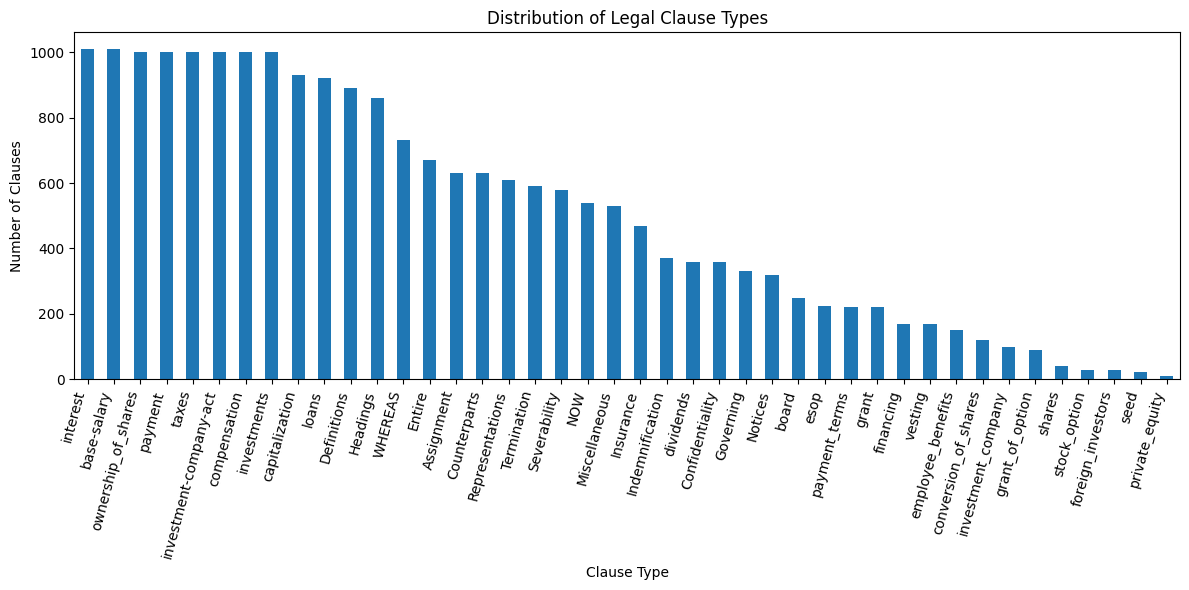

In [12]:
# ============================================================
# STEP 11: VISUALIZE CLAUSE TYPE DISTRIBUTION
# ============================================================
#
# A highly imbalanced dataset may affect evaluation.
#
# For example:
#
#   Payment          → 5,000
#   Confidentiality  → 3,000
#   Insurance        → 500
#
# would mean that some categories have much more data
# than others.
# ============================================================

plt.figure(figsize=(12, 6))

clause_type_counts.plot(
    kind="bar"
)

plt.title("Distribution of Legal Clause Types")
plt.xlabel("Clause Type")
plt.ylabel("Number of Clauses")

plt.xticks(
    rotation=75,
    ha="right"
)

plt.tight_layout()
plt.show()

## 12. Analyze Text Length

In [13]:
# ============================================================
# STEP 12: TEXT LENGTH ANALYSIS
# ============================================================
#
# Legal clauses can range from short sentences to long
# paragraphs.
#
# We calculate:
#
#   - Character count
#   - Word count
#
# This helps us understand the type of text our model
# needs to process.
# ============================================================

# Convert clause text to string first to avoid problems
# if unexpected non-string values exist.
df["clause_text"] = df["clause_text"].fillna("").astype(str)

# Character count.
df["character_count"] = df["clause_text"].str.len()

# Word count using whitespace splitting.
df["word_count"] = (
    df["clause_text"]
    .str.split()
    .str.len()
)

print("Character count statistics:")
display(df["character_count"].describe())

print("\nWord count statistics:")
display(df["word_count"].describe())

Character count statistics:


,character_count
count,21187.000000
mean,605.473781
std,589.784607
min,0.000000
25%,194.000000
50%,394.000000
75%,788.000000
max,2519.000000



Word count statistics:


,word_count
count,21187.000000
mean,98.106622
std,95.228743
min,0.000000
25%,32.000000
50%,64.000000
75%,129.000000
max,1064.000000


## 13. Visualize Word Count

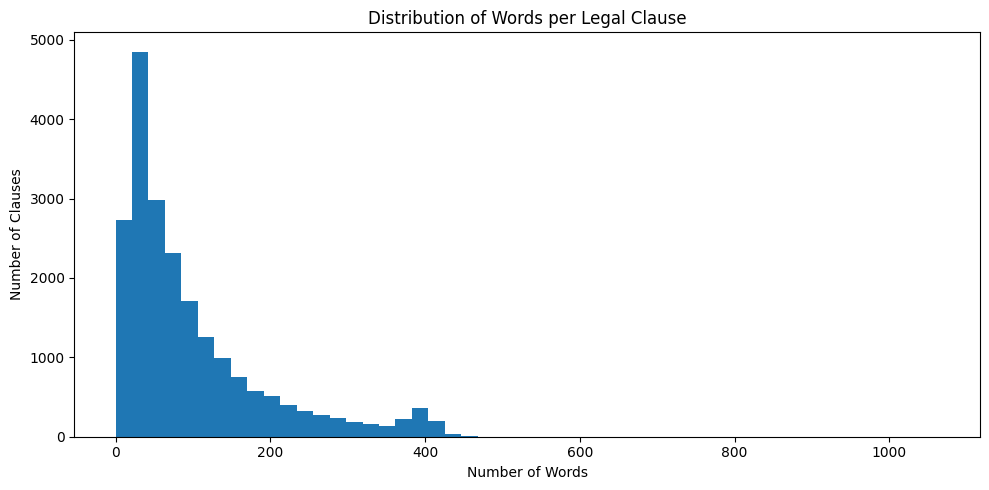

In [14]:
# ============================================================
# STEP 13: VISUALIZE WORD COUNT DISTRIBUTION
# ============================================================
#
# This histogram shows how long the legal clauses generally
# are in terms of number of words.
#
# Understanding this is useful before designing the
# clause-embedding strategy.
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    df["word_count"],
    bins=50
)

plt.title("Distribution of Words per Legal Clause")
plt.xlabel("Number of Words")
plt.ylabel("Number of Clauses")

plt.tight_layout()
plt.show()

## 14. Create the Clean Working Dataset

In [15]:
# ============================================================
# STEP 14: DATA PREPARATION — INITIAL CLEANING
# ============================================================
#
# We now create a clean working dataset.
#
# Cleaning steps:
#
#   1. Keep only the columns required for this NLP project.
#   2. Remove missing/empty clause text.
#   3. Remove duplicate clause text.
#   4. Reset the DataFrame index.
#
# We keep:
#
#   clause_text → NLP input
#   clause_type → metadata / evaluation
# ============================================================

# Keep only the columns needed for the project.
clean_df = df[
    ["clause_text", "clause_type"]
].copy()

# Remove missing values in clause_text.
clean_df = clean_df.dropna(
    subset=["clause_text"]
)

# Remove rows where the clause is empty after stripping spaces.
clean_df["clause_text"] = (
    clean_df["clause_text"]
    .astype(str)
    .str.strip()
)

clean_df = clean_df[
    clean_df["clause_text"] != ""
]

# Remove duplicate clause text.
clean_df = clean_df.drop_duplicates(
    subset=["clause_text"]
)

# Reset index after removing records.
clean_df = clean_df.reset_index(drop=True)

print("Original dataset size:", len(df))
print("Clean dataset size:", len(clean_df))
print("Records removed:", len(df) - len(clean_df))

print("\nClean dataset:")
display(clean_df.head())

Original dataset size: 21187
Clean dataset size: 21073
Records removed: 114

Clean dataset:


,clause_text,clause_type
0,"Make any Investments, except:",investments
1,"No more than 45% of the “value” (as defined in Section 2(a)(41) of the Investment Company Act of 1940, as amended (“Investment Company Act”)) of the Company’s total assets consist of, and no more ...",investments
2,"Make or hold any Investments, except:",investments
3,"The SubAdviser is hereby authorized and directed and hereby agrees, subject to the stated investment policies and restrictions of the Fund as set forth in the Fund's prospectus, summary prospectus...",investments
4,"Make any advance, loan, extension of credit (by way of guaranty or otherwise) or capital contribution to, or purchase any Capital Stock, bonds, notes, debentures or other debt securities of, or an...",investments


## 15. TEXT NORMALIZATION AND TOKENIZATION

In [18]:
# ============================================================
# STEP 15 — TEXT NORMALIZATION AND TOKENIZATION
# ============================================================
#
# Purpose:
# Convert each legal clause from raw text into a list of
# normalized word tokens.
#
# Example:
#
# Original:
# "The receiving party shall maintain confidentiality."
#
# After tokenization:
#
# ["the", "receiving", "party", "shall", "maintain",
#  "confidentiality"]
#
# Why do we need this?
# --------------------
# Word2Vec does not consume a complete paragraph directly.
# It learns from sequences of individual words.
#
# Important legal-NLP decision:
# ----------------------------
# We are NOT aggressively removing stopwords.
#
# Words such as:
#   shall
#   may
#   not
#   unless
#   if
#
# can carry important legal meaning.
# ============================================================

import re


def tokenize(text):
    """
    Convert one legal clause into normalized word tokens.

    Processing:
    1. Convert text to lowercase.
    2. Replace punctuation/special characters with spaces.
    3. Extract meaningful word tokens.

    Parameters
    ----------
    text : str
        Original legal clause.

    Returns
    -------
    list
        List of normalized tokens.
    """

    # Make sure the input is treated as text and convert
    # all characters to lowercase.
    text = str(text).lower()

    # Replace punctuation and special characters with spaces.
    #
    # Example:
    # "party's confidential-information"
    #
    # becomes approximately:
    # "party s confidential information"
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Extract words.
    #
    # We require:
    # - the token to start with a letter
    # - at least one additional alphanumeric character
    #
    # This avoids many one-character noise tokens.
    tokens = re.findall(
        r"\b[a-z][a-z0-9]{1,}\b",
        text
    )

    return tokens


# ------------------------------------------------------------
# Apply the tokenizer to our CLEAN DATASET.
# ------------------------------------------------------------
#
# Notice that we are using clean_df here.
#
# train_df and test_df do NOT exist yet.
#
# We will create them in a later step.
# ------------------------------------------------------------

clean_df["tokens"] = clean_df["clause_text"].apply(tokenize)


# ------------------------------------------------------------
# Display a few examples so that we can verify the result.
# ------------------------------------------------------------

print("TOKENIZATION EXAMPLES")
print("=" * 80)

for i in range(3):

    print(f"\nExample {i + 1}")
    print("-" * 80)

    print("Original clause:")
    print(clean_df.loc[i, "clause_text"])

    print("\nTokens:")
    print(clean_df.loc[i, "tokens"])

    print("\nNumber of tokens:")
    print(len(clean_df.loc[i, "tokens"]))


print("\n" + "=" * 80)
print("Tokenization completed successfully.")
print(f"Total clauses tokenized: {len(clean_df):,}")

TOKENIZATION EXAMPLES

Example 1
--------------------------------------------------------------------------------
Original clause:
Make any Investments, except:

Tokens:
['make', 'any', 'investments', 'except']

Number of tokens:
4

Example 2
--------------------------------------------------------------------------------
Original clause:
No more than 45% of the “value” (as defined in Section 2(a)(41) of the Investment Company Act of 1940, as amended (“Investment Company Act”)) of the Company’s total assets consist of, and no more than 45% of the Company’s net income after taxes is derived from, securities other than “Government Securities” (as defined in Section 2(a)(16) of the Investment Company Act) or money market funds meeting the conditions of Rule 2a-7 of the Investment Company Act.

Tokens:
['no', 'more', 'than', 'of', 'the', 'value', 'as', 'defined', 'in', 'section', 'of', 'the', 'investment', 'company', 'act', 'of', 'as', 'amended', 'investment', 'company', 'act', 'of', 'the'

## 16. Understand Our Tokenization

In [19]:
# ============================================================
# STEP 16 — INSPECT TOKENIZATION QUALITY
# ============================================================
#
# Purpose:
# Understand how many tokens our legal clauses contain after
# preprocessing.
#
# We will check:
#   1. Average token count
#   2. Minimum token count
#   3. Maximum token count
#   4. Median token count
#   5. Shortest clauses
#   6. Longest clauses
#
# This helps us detect unexpected preprocessing problems
# before training Word2Vec.
# ============================================================


# Create a new column containing the number of tokens
# in each legal clause.
clean_df["token_count"] = clean_df["tokens"].apply(len)


# ------------------------------------------------------------
# Basic statistics
# ------------------------------------------------------------

print("TOKEN COUNT STATISTICS")
print("=" * 80)

print(
    f"Average tokens per clause : "
    f"{clean_df['token_count'].mean():.2f}"
)

print(
    f"Minimum tokens             : "
    f"{clean_df['token_count'].min()}"
)

print(
    f"Maximum tokens             : "
    f"{clean_df['token_count'].max()}"
)

print(
    f"Median tokens              : "
    f"{clean_df['token_count'].median():.0f}"
)


# ------------------------------------------------------------
# Find the shortest clauses.
# ------------------------------------------------------------

print("\n\nSHORTEST CLAUSES")
print("=" * 80)

shortest_clauses = (
    clean_df
    .sort_values("token_count")
    .head(5)
)

for _, row in shortest_clauses.iterrows():

    print(f"\nToken count: {row['token_count']}")
    print(f"Clause type: {row['clause_type']}")
    print(row["clause_text"])


# ------------------------------------------------------------
# Find the longest clauses.
# ------------------------------------------------------------

print("\n\nLONGEST CLAUSES")
print("=" * 80)

longest_clauses = (
    clean_df
    .sort_values(
        "token_count",
        ascending=False
    )
    .head(5)
)

for _, row in longest_clauses.iterrows():

    print(f"\nToken count: {row['token_count']}")
    print(f"Clause type: {row['clause_type']}")

    # Display only the first 500 characters so that
    # a very long legal clause does not flood the notebook.
    print(row["clause_text"][:500])

TOKEN COUNT STATISTICS
Average tokens per clause : 95.46
Minimum tokens             : 0
Maximum tokens             : 438
Median tokens              : 62


SHORTEST CLAUSES

Token count: 0
Clause type: esop
1.1(b).

Token count: 0
Clause type: Miscellaneous
­________________________________________________________ ________________________________________________________________________________________________________________________________________________________________________

Token count: 1
Clause type: esop
Section 10.1(c)

Token count: 1
Clause type: interest
(a) [Reserved]

Token count: 1
Clause type: Definitions
Section 1.01


LONGEST CLAUSES

Token count: 438
Clause type: taxes
All Taxes (as defined below) which are due and payable by the Company or claimed and asserted by any Taxing Authority (as defined below) to be due and payable by the Company have been timely paid. At Closing, there shall be no Taxes due or payable to any Taxing Authority with respect to any period prior

## 17. Train/Test Split

In [21]:
# ============================================================
# STEP 17 — TRAIN / TEST SPLIT
# ============================================================
#
# Purpose:
# Divide our cleaned legal dataset into:
#
#   80% TRAINING DATA
#   20% TEST DATA
#
# The Word2Vec model and TF-IDF vocabulary will be learned
# using TRAINING DATA only.
#
# The TEST DATA will later be used as unseen queries for
# evaluating our retrieval system.
#
# We use stratification based on clause_type so that the
# distribution of clause categories is maintained as much
# as possible in both datasets.
# ============================================================


# ------------------------------------------------------------
# Create row indices for our dataset.
# ------------------------------------------------------------

indices = np.arange(len(clean_df))


# ------------------------------------------------------------
# Split the indices into training and testing sets.
# ------------------------------------------------------------
#
# test_size=0.20
#     -> 20% goes to the test set
#
# random_state=42
#     -> makes the split reproducible
#
# stratify=clean_df["clause_type"]
#     -> preserves the distribution of clause types
#        as much as possible
# ------------------------------------------------------------

train_indices, test_indices = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=clean_df["clause_type"]
)


# ------------------------------------------------------------
# Create the actual DataFrames.
# ------------------------------------------------------------

train_df = (
    clean_df
    .iloc[train_indices]
    .reset_index(drop=True)
)

test_df = (
    clean_df
    .iloc[test_indices]
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Display the resulting dataset sizes.
# ------------------------------------------------------------

print("TRAIN / TEST SPLIT COMPLETED")
print("=" * 80)

print(f"Total clauses : {len(clean_df):,}")
print(f"Training     : {len(train_df):,}")
print(f"Testing      : {len(test_df):,}")

print(
    f"\nTraining percentage: "
    f"{len(train_df) / len(clean_df) * 100:.2f}%"
)

print(
    f"Testing percentage : "
    f"{len(test_df) / len(clean_df) * 100:.2f}%"
)


# ------------------------------------------------------------
# Verify clause-type distribution.
# ------------------------------------------------------------

print("\n\nCLAUSE TYPE DISTRIBUTION")
print("=" * 80)

distribution_check = pd.DataFrame({
    "Total": clean_df["clause_type"].value_counts(),
    "Train": train_df["clause_type"].value_counts(),
    "Test": test_df["clause_type"].value_counts()
}).fillna(0).astype(int)

print(distribution_check)

TRAIN / TEST SPLIT COMPLETED
Total clauses : 21,073
Training     : 16,858
Testing      : 4,215

Training percentage: 80.00%
Testing percentage : 20.00%


CLAUSE TYPE DISTRIBUTION
                        Total  Train  Test
clause_type                               
Assignment                630    504   126
Confidentiality           360    288    72
Counterparts              609    487   122
Definitions               886    709   177
Entire                    670    536   134
Governing                 330    264    66
Headings                  858    686   172
Indemnification           370    296    74
Insurance                 470    376    94
Miscellaneous             528    422   106
NOW                       540    432   108
Notices                   320    256    64
Representations           610    488   122
Severability              579    463   116
Termination               589    471   118
WHEREAS                   730    584   146
base-salary              1000    800   200
boar

## 18. Build the Word2Vec Training Corpus

In [22]:
# ============================================================
# STEP 18 — BUILD THE WORD2VEC TRAINING CORPUS
# ============================================================
#
# Purpose:
# Extract the tokenized clauses from train_df and convert them
# into the list-of-lists structure expected by Word2Vec.
#
# Example:
#
# [
#     ["party", "shall", "maintain", "confidentiality"],
#     ["payment", "shall", "be", "made", "within", "days"],
#     ["agreement", "may", "be", "terminated", ...]
# ]
#
# Each inner list represents one legal clause.
# ============================================================


# Extract the token lists from the training DataFrame.
train_tokens = train_df["tokens"].tolist()


# We keep the test tokens separate.
# We are NOT using them to train Word2Vec.
test_tokens = test_df["tokens"].tolist()


# ------------------------------------------------------------
# Verify the corpus structure.
# ------------------------------------------------------------

print("WORD2VEC CORPUS")
print("=" * 80)

print(f"Training clauses: {len(train_tokens):,}")
print(f"Testing clauses : {len(test_tokens):,}")


print("\nFirst training clause:")
print(train_tokens[0])


print("\nNumber of tokens in first training clause:")
print(len(train_tokens[0]))

WORD2VEC CORPUS
Training clauses: 16,858
Testing clauses : 4,215

First training clause:
['other', 'than', 'permitted', 'investments', 'the', 'company', 'has', 'not', 'acquired', 'an', 'equity', 'interest', 'in', 'acquired', 'all', 'or', 'substantially', 'all', 'of', 'the', 'assets', 'of', 'loaned', 'money', 'extended', 'credit', 'or', 'made', 'advances', 'to', 'or', 'made', 'deposits', 'with', 'other', 'than', 'deposits', 'or', 'advances', 'in', 'relation', 'to', 'the', 'payment', 'for', 'goods', 'and', 'equipment', 'in', 'the', 'ordinary', 'course', 'of', 'business', 'the', 'making', 'of', 'which', 'is', 'expressly', 'contemplated', 'pursuant', 'to', 'the', 'operative', 'documents', 'any', 'person']

Number of tokens in first training clause:
68


## 19. Train the Word2Vec Model

In [23]:
# ============================================================
# STEP 19 — TRAIN THE WORD2VEC MODEL
# ============================================================
#
# Purpose:
# Train a Word2Vec model using ONLY our training corpus.
#
# Word2Vec learns a numerical vector representation for words
# based on the context in which those words appear.
#
# Input:
#     train_tokens
#
# Output:
#     w2v
#
# The resulting model will contain a vector for every word
# that satisfies the min_count requirement.
# ============================================================


# ------------------------------------------------------------
# Create and train the Word2Vec model.
# ------------------------------------------------------------

w2v = Word2Vec(

    # Our tokenized legal clauses.
    # IMPORTANT:
    # This contains TRAINING data only.
    sentences=train_tokens,

    # --------------------------------------------------------
    # vector_size
    # --------------------------------------------------------
    # Each word will be represented using 100 numbers.
    #
    # Example:
    #
    # "confidentiality"
    #       ↓
    # [0.12, -0.31, 0.45, ..., 0.07]
    #
    # Larger vectors can capture more information but require
    # more memory and training time.
    vector_size=100,


    # --------------------------------------------------------
    # window
    # --------------------------------------------------------
    # Word2Vec looks at nearby words when learning.
    #
    # window=5 means it considers a context of approximately
    # five words around the target word.
    #
    # Example:
    #
    # party shall maintain confidentiality of all information
    #              ↑
    #          target word
    #
    # Nearby words help Word2Vec understand usage/context.
    window=5,


    # --------------------------------------------------------
    # min_count
    # --------------------------------------------------------
    # Ignore words that occur fewer than 2 times.
    #
    # A word appearing only once provides very little evidence
    # for learning its semantic relationships.
    min_count=2,


    # --------------------------------------------------------
    # workers
    # --------------------------------------------------------
    # Number of CPU threads used during training.
    #
    # Using multiple workers can make training faster.
    workers=4,


    # --------------------------------------------------------
    # sg
    # --------------------------------------------------------
    # sg=1 means Skip-gram.
    #
    # Skip-gram:
    #
    #       TARGET WORD
    #            ↓
    #   predict surrounding words
    #
    # We are therefore asking the model to learn which words
    # tend to appear around a given word.
    sg=1,


    # --------------------------------------------------------
    # negative
    # --------------------------------------------------------
    # Number of negative samples used during training.
    #
    # This helps the model distinguish real word/context
    # relationships from randomly selected relationships.
    negative=10,


    # --------------------------------------------------------
    # epochs
    # --------------------------------------------------------
    # Number of times the complete training corpus is processed.
    epochs=10,


    # --------------------------------------------------------
    # seed
    # --------------------------------------------------------
    # Fixes the random seed so that our experiment is
    # reproducible.
    seed=42
)


# ------------------------------------------------------------
# Display information about the trained model.
# ------------------------------------------------------------

print("WORD2VEC TRAINING COMPLETED")
print("=" * 80)

print(f"Vector dimensions : {w2v.vector_size}")
print(f"Vocabulary size   : {len(w2v.wv.index_to_key):,}")
print(f"Context window    : 5")
print(f"Minimum frequency : 2")
print(f"Architecture      : Skip-gram")
print(f"Negative samples  : 10")
print(f"Training epochs   : 10")

WORD2VEC TRAINING COMPLETED
Vector dimensions : 100
Vocabulary size   : 8,242
Context window    : 5
Minimum frequency : 2
Architecture      : Skip-gram
Negative samples  : 10
Training epochs   : 10


## 20. Inspect the Learned Vocabulary

In [24]:
# ============================================================
# STEP 20 — INSPECT THE WORD2VEC VOCABULARY
# ============================================================
#
# Purpose:
# Understand what words Word2Vec learned from our legal
# training corpus.
#
# We will:
#   1. Count the vocabulary
#   2. Display some learned words
#   3. Inspect one actual word vector
# ============================================================


# Get all words known by Word2Vec.
vocabulary = w2v.wv.index_to_key


# ------------------------------------------------------------
# Display vocabulary information.
# ------------------------------------------------------------

print("WORD2VEC VOCABULARY")
print("=" * 80)

print(f"Total learned words: {len(vocabulary):,}")


# Display the first 50 words.
print("\nFirst 50 vocabulary words:")
print(vocabulary[:50])


# ------------------------------------------------------------
# Inspect one word vector.
# ------------------------------------------------------------

word = "confidentiality"


print("\n" + "=" * 80)
print(f"INSPECTING WORD VECTOR: '{word}'")
print("=" * 80)


if word in w2v.wv:

    vector = w2v.wv[word]

    print(f"Vector shape: {vector.shape}")

    print("\nFirst 20 values of the vector:")
    print(vector[:20])

else:

    print(
        f"'{word}' was not found in the vocabulary."
    )

WORD2VEC VOCABULARY
Total learned words: 8,242

First 50 vocabulary words:
['the', 'of', 'and', 'to', 'or', 'in', 'any', 'be', 'shall', 'by', 'as', 'such', 'company', 'agreement', 'this', 'for', 'other', 'with', 'all', 'on', 'not', 'is', 'shares', 'that', 'stock', 'date', 'are', 'which', 'its', 'each', 'may', 'at', 'an', 'under', 'will', 'have', 'time', 'interest', 'party', 'from', 'no', 'section', 'if', 'respect', 'securities', 'payment', 'has', 'outstanding', 'subject', 'except']

INSPECTING WORD VECTOR: 'confidentiality'
Vector shape: (100,)

First 20 values of the vector:
[ 0.34566706  0.43449098 -0.25424042 -0.02549991 -0.19672315  0.88246346
  0.17905414 -0.07765904  0.0035065  -0.558304   -0.53197247 -0.06884549
 -0.64849836  0.8410719  -0.12031443 -0.41281095 -0.25896356 -0.38693586
 -0.38960138 -0.33194748]


## 21. Explore Similar Words

In [25]:
# ============================================================
# STEP 21 — EXPLORE WORD SEMANTIC RELATIONSHIPS
# ============================================================
#
# Purpose:
# Check whether Word2Vec has learned useful relationships
# between legal words.
#
# IMPORTANT:
# Word2Vec is learning from statistical patterns in our
# dataset. It is NOT a legal dictionary.
#
# Therefore, the results are an inspection tool rather than
# proof that the model understands legal meaning perfectly.
# ============================================================


# Legal concepts we would like to inspect.
words_to_test = [
    "confidentiality",
    "payment",
    "termination",
    "agreement",
    "compliance"
]


for word in words_to_test:

    print("\n" + "=" * 80)
    print(f"WORDS SIMILAR TO: '{word}'")
    print("=" * 80)


    # Check whether this word exists in the learned vocabulary.
    if word not in w2v.wv:

        print(
            f"'{word}' is not present in the Word2Vec vocabulary."
        )

        continue


    # Find the 10 words whose vectors are closest to the
    # vector of our target word.
    similar_words = w2v.wv.most_similar(
        word,
        topn=10
    )


    # Display the results.
    for similar_word, similarity_score in similar_words:

        print(
            f"{similar_word:25s}"
            f" similarity = {similarity_score:.4f}"
        )


WORDS SIMILAR TO: 'confidentiality'
secrecy                   similarity = 0.7110
nondisclosure             similarity = 0.6587
disclosing                similarity = 0.6552
confidential              similarity = 0.6516
dawson                    similarity = 0.5998
information               similarity = 0.5933
invention                 similarity = 0.5907
confidentially            similarity = 0.5846
disclose                  similarity = 0.5677
proprietary               similarity = 0.5661

WORDS SIMILAR TO: 'payment'
payments                  similarity = 0.6889
shipments                 similarity = 0.6452
demanded                  similarity = 0.6166
overpayment               similarity = 0.6129
cumulated                 similarity = 0.6082
justify                   similarity = 0.6063
intervening               similarity = 0.6055
gc                        similarity = 0.6038
warehousing               similarity = 0.6037
unt                       similarity = 0.5989

WORDS SIMILAR

## 22. Fit TF-IDF on Training Data

In [26]:
# ============================================================
# STEP 22 — BUILD THE TF-IDF WEIGHTING LAYER
# ============================================================
#
# Purpose:
# Learn how informative each word is within our legal training
# corpus.
#
# We are NOT using TF-IDF as our final semantic representation.
#
# Instead:
#
#     Word2Vec  -> tells us what a word represents semantically
#     TF-IDF    -> tells us how important that word is
#
# We will combine these two later.
#
# IMPORTANT:
# The TF-IDF vocabulary is fitted using TRAINING DATA ONLY.
# This prevents information leakage from the test set.
# ============================================================


# ------------------------------------------------------------
# Create the TF-IDF vectorizer.
# ------------------------------------------------------------
#
# tokenizer=tokenize
#     Use the same tokenizer that we created earlier.
#
# token_pattern=None
#     Because we are supplying our own tokenizer.
#
# lowercase=False
#     Our tokenizer already converts text to lowercase.
#
# min_df=2
#     Ignore words that occur in only one training document.
#
# max_features=50000
#     Put a reasonable upper limit on vocabulary size.
#
# sublinear_tf=True
#     Use logarithmic scaling for term frequency. This reduces
#     the influence of extremely frequent terms.
# ------------------------------------------------------------

tfidf = TfidfVectorizer(
    tokenizer=tokenize,
    token_pattern=None,
    lowercase=False,
    min_df=2,
    max_features=50000,
    sublinear_tf=True
)


# ------------------------------------------------------------
# FIT the TF-IDF model on TRAINING DATA ONLY.
# ------------------------------------------------------------
#
# fit() means:
#
# "Learn the vocabulary and IDF statistics."
#
# We are deliberately NOT doing:
#
# tfidf.fit(clean_df["clause_text"])
#
# because that would allow test data to influence the
# vocabulary/statistics.
# ------------------------------------------------------------

tfidf.fit(train_df["clause_text"])


# ------------------------------------------------------------
# Extract the learned vocabulary.
# ------------------------------------------------------------

tfidf_vocabulary = tfidf.get_feature_names_out()


# ------------------------------------------------------------
# Extract the IDF value associated with every vocabulary word.
# ------------------------------------------------------------
#
# Example:
#
# tfidf_vocabulary:
# ["agreement", "confidentiality", "payment", ...]
#
# tfidf.idf_:
# [1.52, 2.71, 1.94, ...]
#
# We combine them into a dictionary so we can easily look up
# the IDF weight of a word later.
# ------------------------------------------------------------

idf_map = dict(
    zip(
        tfidf_vocabulary,
        tfidf.idf_
    )
)


# ------------------------------------------------------------
# Display information about the learned TF-IDF vocabulary.
# ------------------------------------------------------------

print("TF-IDF TRAINING COMPLETED")
print("=" * 80)

print(
    f"TF-IDF vocabulary size: "
    f"{len(tfidf_vocabulary):,}"
)

print(
    f"Number of IDF weights : "
    f"{len(idf_map):,}"
)


# ------------------------------------------------------------
# Display a few example words and their IDF weights.
# ------------------------------------------------------------

print("\nSample IDF weights:")
print("-" * 80)

for word in tfidf_vocabulary[:20]:

    print(
        f"{word:25s} "
        f"IDF = {idf_map[word]:.4f}"
    )

TF-IDF TRAINING COMPLETED
TF-IDF vocabulary size: 6,854
Number of IDF weights : 6,854

Sample IDF weights:
--------------------------------------------------------------------------------
a1                        IDF = 8.9409
a2                        IDF = 9.6340
aa                        IDF = 8.3347
aaron                     IDF = 9.6340
aau                       IDF = 9.6340
ab                        IDF = 8.5354
aba                       IDF = 9.1232
abandon                   IDF = 9.6340
abandoned                 IDF = 7.0951
abandonment               IDF = 9.1232
abatement                 IDF = 8.4301
abide                     IDF = 9.3463
ability                   IDF = 6.0882
abl                       IDF = 9.6340
able                      IDF = 6.7073
abolish                   IDF = 8.9409
about                     IDF = 6.6055
above                     IDF = 4.5464
abr                       IDF = 6.6722
abrogate                  IDF = 9.1232


## 23. Inspect Important Legal Words

In [27]:
# ============================================================
# STEP 23 — INSPECT TF-IDF WEIGHTS FOR LEGAL TERMS
# ============================================================
#
# Purpose:
# See how the TF-IDF layer assigns importance to selected
# legal vocabulary.
#
# This is an inspection step so that we understand what our
# weighting mechanism is doing.
# ============================================================


legal_words = [
    "confidentiality",
    "confidential",
    "disclosure",
    "payment",
    "pay",
    "termination",
    "terminate",
    "agreement",
    "compliance",
    "information",
    "party",
    "shall",
    "may",
    "not"
]


print("LEGAL WORD TF-IDF WEIGHTS")
print("=" * 80)


for word in legal_words:

    # Check whether the word exists in the TF-IDF vocabulary.
    if word in idf_map:

        print(
            f"{word:20s} "
            f"IDF = {idf_map[word]:.4f}"
        )

    else:

        print(
            f"{word:20s} "
            f"NOT FOUND"
        )

LEGAL WORD TF-IDF WEIGHTS
confidentiality      IDF = 5.5286
confidential         IDF = 5.0697
disclosure           IDF = 4.3994
payment              IDF = 3.1741
pay                  IDF = 3.0768
termination          IDF = 4.1801
terminate            IDF = 4.8862
agreement            IDF = 1.7497
compliance           IDF = 4.8057
information          IDF = 4.2949
party                IDF = 3.0641
shall                IDF = 1.6048
may                  IDF = 2.3071
not                  IDF = 1.9526


## 24. Build the Clause Embedding Function

In [28]:
# ============================================================
# STEP 24 — CREATE THE CLAUSE EMBEDDING FUNCTION
# ============================================================
#
# Purpose:
# Convert an entire legal clause into ONE numerical vector.
#
# Our approach:
#
#     Legal clause
#          ↓
#       tokenize
#          ↓
#    individual words
#          ↓
#      Word2Vec
#          ↓
#   word vectors
#          ↓
#      TF-IDF
#          ↓
#   importance weights
#          ↓
#   weighted average
#          ↓
#   ONE CLAUSE VECTOR
#
# The resulting vector will have 100 dimensions because our
# Word2Vec model uses vector_size=100.
# ============================================================


def sentence_vector(tokens):
    """
    Convert a list of tokens into one clause-level embedding.

    Each token contributes its Word2Vec vector, weighted by
    its TF-IDF IDF value.

    Parameters
    ----------
    tokens : list
        Tokenized legal clause.

    Returns
    -------
    numpy.ndarray
        100-dimensional clause embedding.
    """

    # These lists will store:
    #
    # 1. Word2Vec vectors
    # 2. Their corresponding importance weights
    #
    vectors = []
    weights = []


    # --------------------------------------------------------
    # Process every token in the clause.
    # --------------------------------------------------------

    for token in tokens:

        # We can use a word only when Word2Vec knows it AND
        # TF-IDF has an IDF weight for it.
        if token in w2v.wv and token in idf_map:

            # Get the learned Word2Vec vector.
            vectors.append(
                w2v.wv[token]
            )

            # Get the TF-IDF IDF weight.
            weights.append(
                idf_map[token]
            )


    # --------------------------------------------------------
    # Fallback:
    #
    # It is possible that a token exists in Word2Vec but not
    # in our TF-IDF vocabulary.
    #
    # In that case, use the Word2Vec vector with equal weight.
    # --------------------------------------------------------

    if not vectors:

        for token in tokens:

            if token in w2v.wv:

                vectors.append(
                    w2v.wv[token]
                )

                # Equal weighting for the fallback case.
                weights.append(1.0)


    # --------------------------------------------------------
    # If absolutely no usable words exist, return a zero vector.
    # --------------------------------------------------------

    if not vectors:

        return np.zeros(
            w2v.vector_size,
            dtype=np.float32
        )


    # Convert the vectors into a NumPy matrix.
    vector_array = np.asarray(
        vectors,
        dtype=np.float32
    )


    # Convert weights into a column vector.
    #
    # Example:
    #
    # [1.2, 2.4, 1.8]
    #
    # becomes:
    #
    # [[1.2],
    #  [2.4],
    #  [1.8]]
    #
    weight_array = np.asarray(
        weights,
        dtype=np.float32
    ).reshape(-1, 1)


    # --------------------------------------------------------
    # Calculate the TF-IDF weighted average.
    # --------------------------------------------------------
    #
    # Each word vector is multiplied by its importance weight.
    #
    # Then all weighted vectors are summed and divided by the
    # total weight.
    # --------------------------------------------------------

    weighted_vector = (
        vector_array * weight_array
    ).sum(axis=0) / max(
        weight_array.sum(),
        1e-8
    )


    return weighted_vector.astype(
        np.float32
    )


print("Clause embedding function created successfully.")
print(
    f"Output dimensionality: "
    f"{w2v.vector_size}"
)

Clause embedding function created successfully.
Output dimensionality: 100


## 25. Test the Clause Embedding Function

In [29]:
# ============================================================
# STEP 25 — TEST ONE CLAUSE EMBEDDING
# ============================================================
#
# Purpose:
# Verify that our sentence_vector() function successfully
# converts one legal clause into a numerical vector.
# ============================================================


# Take the first training clause.
sample_tokens = train_df.loc[0, "tokens"]


# Create its clause-level embedding.
sample_vector = sentence_vector(sample_tokens)


# ------------------------------------------------------------
# Inspect the result.
# ------------------------------------------------------------

print("SAMPLE CLAUSE EMBEDDING")
print("=" * 80)

print("Original clause:")
print(train_df.loc[0, "clause_text"])


print("\nTokens:")
print(sample_tokens)


print("\nEmbedding shape:")
print(sample_vector.shape)


print("\nFirst 20 embedding values:")
print(sample_vector[:20])


print("\nVector data type:")
print(sample_vector.dtype)

SAMPLE CLAUSE EMBEDDING
Original clause:
Other than Permitted Investments, the Company has not acquired an equity interest in, acquired all or substantially all of the assets of, loaned money, extended credit or made advances to, or made deposits with (other than deposits or advances in relation to the payment for goods and equipment in the ordinary course of business the making of which is expressly contemplated pursuant to the Operative Documents), any Person.

Tokens:
['other', 'than', 'permitted', 'investments', 'the', 'company', 'has', 'not', 'acquired', 'an', 'equity', 'interest', 'in', 'acquired', 'all', 'or', 'substantially', 'all', 'of', 'the', 'assets', 'of', 'loaned', 'money', 'extended', 'credit', 'or', 'made', 'advances', 'to', 'or', 'made', 'deposits', 'with', 'other', 'than', 'deposits', 'or', 'advances', 'in', 'relation', 'to', 'the', 'payment', 'for', 'goods', 'and', 'equipment', 'in', 'the', 'ordinary', 'course', 'of', 'business', 'the', 'making', 'of', 'which', 'is',

## 26. Create Embeddings for the Entire Dataset

In [30]:
# ============================================================
# STEP 26 — CREATE CLAUSE EMBEDDINGS FOR TRAIN AND TEST DATA
# ============================================================
#
# Purpose:
# Convert every legal clause into a 100-dimensional numerical
# representation.
#
# Training clauses:
#     Will become our searchable knowledge base.
#
# Testing clauses:
#     Will later act as unseen queries during evaluation.
# ============================================================


# ------------------------------------------------------------
# Create embeddings for all TRAINING clauses.
# ------------------------------------------------------------

print("Creating training embeddings...")

train_embeddings_raw = np.vstack([
    sentence_vector(tokens)
    for tokens in train_tokens
]).astype(np.float32)


# ------------------------------------------------------------
# Create embeddings for all TEST clauses.
# ------------------------------------------------------------

print("Creating test embeddings...")

test_embeddings_raw = np.vstack([
    sentence_vector(tokens)
    for tokens in test_tokens
]).astype(np.float32)


# ------------------------------------------------------------
# Display the resulting shapes.
# ------------------------------------------------------------

print("\nCLAUSE EMBEDDING CREATION COMPLETED")
print("=" * 80)

print(
    f"Training embeddings shape: "
    f"{train_embeddings_raw.shape}"
)

print(
    f"Test embeddings shape    : "
    f"{test_embeddings_raw.shape}"
)

Creating training embeddings...
Creating test embeddings...

CLAUSE EMBEDDING CREATION COMPLETED
Training embeddings shape: (16858, 100)
Test embeddings shape    : (4215, 100)


## 27. Normalize the clause embeddings

In [31]:
# Normalize each clause vector so that its length becomes 1.
# This keeps all clause vectors on the same scale.
train_embeddings = normalize(train_embeddings_raw).astype(np.float32)
test_embeddings = normalize(test_embeddings_raw).astype(np.float32)

print("Train embeddings shape:", train_embeddings.shape)
print("Test embeddings shape:", test_embeddings.shape)


train_vector_norm = np.linalg.norm(train_embeddings[0])

print("Norm of first normalized clause vector:", train_vector_norm)

Train embeddings shape: (16858, 100)
Test embeddings shape: (4215, 100)
Norm of first normalized clause vector: 0.99999994


## 28. Build the Semantic Search Engine

In [32]:
def semantic_search(query, top_k=5):
    """
    Find the most semantically similar legal clauses
    for a given query.
    """

    # ---------------------------------------------------------
    # 1. Convert the user's query into tokens
    # ---------------------------------------------------------
    query_tokens = tokenize(query)

    # ---------------------------------------------------------
    # 2. Convert the query tokens into ONE 100-dimensional
    #    TF-IDF weighted Word2Vec vector
    # ---------------------------------------------------------
    query_vector = sentence_vector(query_tokens)

    # ---------------------------------------------------------
    # 3. Normalize the query vector
    # ---------------------------------------------------------
    query_norm = query_vector / max(
        np.linalg.norm(query_vector),
        1e-8
    )

    # ---------------------------------------------------------
    # 4. Compare the query vector with every training clause
    #
    #    Because both vectors are normalized,
    #    dot product = cosine similarity
    # ---------------------------------------------------------
    scores = train_embeddings @ query_norm

    # ---------------------------------------------------------
    # 5. Get the indexes of the Top-K highest scores
    # ---------------------------------------------------------
    top_indices = np.argsort(-scores)[:top_k]

    # ---------------------------------------------------------
    # 6. Create a readable result table
    # ---------------------------------------------------------
    results = train_df.iloc[top_indices][
        ["clause_text", "clause_type"]
    ].copy()

    # Add similarity score
    results["similarity_score"] = scores[top_indices]

    # Add ranking
    results["rank"] = np.arange(
        1,
        len(results) + 1
    )

    # Arrange columns
    results = results[
        [
            "rank",
            "similarity_score",
            "clause_type",
            "clause_text"
        ]
    ]

    return results

## 29. Test first semantic search

In [33]:
query = """
The receiving party must keep all confidential information
secret and must not disclose it to unauthorized persons.
"""

results = semantic_search(query, top_k=5)

results

,rank,similarity_score,clause_type,clause_text
10804,1,0.949026,Confidentiality,"(a) During the term of this Agreement and thereafter, the parties hereto shall, and shall instruct their respective Representatives to, maintain in confidence and not disclose the other party’s fi..."
16340,2,0.947359,Confidentiality,"(a) During the Term and thereafter, the Parties hereto shall, and shall instruct their respective Representatives to, maintain in confidence and not disclose or use the other Party’s financial, te..."
1378,3,0.946419,Confidentiality,"(a) Except as may otherwise be required by applicable law, all information and data provided by the Parties to one another pursuant to this Agreement and marked “Confidential” or otherwise identif..."
16319,4,0.945142,Confidentiality,"During the Term, each party will have access to certain confidential information of the other concerning such party’s business, including such party’s products, services, technical data, trade sec..."
13234,5,0.945116,Confidentiality,"Each Finance Party agrees to keep all Confidential Information confidential and not to disclose it to anyone, save to the extent permitted by Clause 44.2 (Disclosure of Confidential Information) a..."


### Test 1 - Payment

In [34]:
payment_query = """
The buyer shall make payment for the services within thirty days
after receiving the invoice.
"""

semantic_search(payment_query, top_k=5)

,rank,similarity_score,clause_type,clause_text
15060,1,0.935063,payment_terms,9.1 Customer shall pay to TAEC all amounts due hereunder within thirty (30) days of the date of TAEC’s invoice therefor.
6877,2,0.931346,payment,Payment shall be made by County within thirty (30) days of receipt of invoice.
5886,3,0.926083,payment,"1. Amounts payable under this Agreement are due and payable within thirty (30) days after the bill date of USWC's invoice. During the initial three billing cycles of this Agreement, Reseller and U..."
5268,4,0.919447,payment,Payment is due thirty days after the date of the invoice.
10765,5,0.917334,payment_terms,"Mikart shall invoice Vertical for the price of the Product sold at the time of shipment, and Vertical shall pay each such invoice within thirty (30) days after its receipt thereof."


### Test 2 - Termination

In [35]:
termination_query = """
Either party may terminate this agreement by providing written notice
to the other party.
"""

semantic_search(termination_query, top_k=5)

,rank,similarity_score,clause_type,clause_text
5580,1,0.912669,Termination,8.0 The parties may terminate this Agreement by three methods. (i) Either party may terminate this Agreement for cause with a thirty-day written notice to the other party; (ii) either party may te...
10339,2,0.909146,Termination,"The Company and Advisor may terminate this Agreement prior to the expiration of the Primary Term upon thirty (30) days written notice with mutual written consent. Failing to have mutual consent, w..."
7490,3,0.908508,Termination,This Agreement may be terminated by either Party upon written notice to the other Party for any reason which shall be effective five (5) business days from the date of such notice. This Agreement ...
4333,4,0.907757,Termination,"9.1 This Agreement may be terminated by any party in its entirety or with respect to one, some or all Portfolios for any reason by sixty (60) days advance written notice delivered to the other par..."
386,5,0.907074,Termination,6.1 This Agreement may be terminated by either party for any reason by ninety (90) days advance written notice delivered to the other party.


### Test 3 - Compliance

In [36]:
compliance_query = """
The parties must comply with all applicable laws and regulatory
requirements.
"""

semantic_search(compliance_query, top_k=5)

,rank,similarity_score,clause_type,clause_text
4786,1,0.860821,Miscellaneous,"12.1 Governing Law, Regulatory Authority, and Rules The validity, interpretation and enforcement of this Agreement and each of its provisions shall be governed by the laws of the state of (where t..."
5201,2,0.856065,taxes,"11.1 The Parties agree to follow all applicable tax laws and regulations, consistent with FERC policy and Internal Revenue Service requirements."
849,3,0.847550,Representations,"and Warranties. 3.1 The Company represents and warrants (i) that it is an insurance company duly organized and in good standing under the laws of the State of Texas and has full corporate power, a..."
12608,4,0.836198,Confidentiality,"Each Lender agrees that it will not disclose without the prior consent of the Borrower Representative (other than to its employees, its Subsidiaries, another Lender, an Affiliate of a Lender or to..."
9568,5,0.835946,taxes,"Any payment required under this Agreement shall be subject to all requirements of the law with regard to the withholding of taxes, filing, making of reports and the like, and the Company shall use..."


## 30. Evaluate the Semantic Search Engine

In [38]:
def evaluate_retrieval(test_data, top_k_values=(1, 3, 5, 10)):
    """
    Evaluate retrieval using clause_type as a weak relevance proxy.

    A retrieved clause is considered relevant when its clause_type
    matches the query clause's clause_type.
    """

    recall_results = {
        k: []
        for k in top_k_values
    }

    top1_matches = []

    for _, query_row in test_data.iterrows():

        # The test clause acts as the query.
        query_text = query_row["clause_text"]
        expected_type = query_row["clause_type"]

        # Retrieve only from the training index.
        query_tokens = tokenize(query_text)
        query_vector = sentence_vector(query_tokens)

        query_norm = query_vector / max(
            np.linalg.norm(query_vector),
            1e-8
        )

        # Compare query against all training clause vectors.
        scores = train_embeddings @ query_norm

        # Sort from highest similarity to lowest similarity.
        ranked_indices = np.argsort(-scores)

        # Evaluate different Top-K values.
        for k in top_k_values:
            top_indices = ranked_indices[:k]

            retrieved_types = train_df.iloc[
                top_indices
            ]["clause_type"].tolist()

            # Check whether at least one relevant clause
            # appears in the Top-K results.
            hit = expected_type in retrieved_types

            recall_results[k].append(int(hit))

        # Check whether the first result has the expected type.
        top1_type = train_df.iloc[
            ranked_indices[0]
        ]["clause_type"]

        top1_matches.append(
            int(top1_type == expected_type)
        )

    # Calculate average hit rate for every K.
    metrics = {}

    for k in top_k_values:
        metrics[f"Recall@{k}"] = np.mean(
            recall_results[k]
        )

    metrics["Top1_Type_Agreement"] = np.mean(
        top1_matches
    )

    return metrics

evaluation_metrics = evaluate_retrieval(test_df, top_k_values=(1, 3, 5, 10))

print(evaluation_metrics)

print("**********Evaluation Metrics*******")

for metric_name, metric_value in evaluation_metrics.items():
    print(
        f"{metric_name}: "
        f"{metric_value:.4f} "
        f"({metric_value * 100:.2f}%)"
    )

{'Recall@1': np.float64(0.8759193357058126), 'Recall@3': np.float64(0.9340450771055753), 'Recall@5': np.float64(0.9489916963226572), 'Recall@10': np.float64(0.9665480427046264), 'Top1_Type_Agreement': np.float64(0.8759193357058126)}
**********Evaluation Metrics*******
Recall@1: 0.8759 (87.59%)
Recall@3: 0.9340 (93.40%)
Recall@5: 0.9490 (94.90%)
Recall@10: 0.9665 (96.65%)
Top1_Type_Agreement: 0.8759 (87.59%)


## 31. Test with Unseen Legal Clauses

### Test 1 — Unseen confidentiality clause

In [39]:
unseen_confidentiality = """
All information received by the receiving party from the disclosing
party shall be kept strictly confidential and shall not be revealed
to any third party without prior written consent.
"""

semantic_search(unseen_confidentiality, top_k=5)

,rank,similarity_score,clause_type,clause_text
3467,1,0.961143,Confidentiality,"Each Party (referred to as the ""Receiving Party"" in this Article VII) acknowledges and agrees that the information which it receives from any of the other Parties (referred to as the ""Disclosing P..."
1378,2,0.950760,Confidentiality,"(a) Except as may otherwise be required by applicable law, all information and data provided by the Parties to one another pursuant to this Agreement and marked “Confidential” or otherwise identif..."
12725,3,0.950325,Confidentiality,"Any Confidential Information will not without prior written consent of the owning Party or as otherwise provided under this Agreement be used, published or disclosed. The foregoing obligations sha..."
4339,4,0.946038,Confidentiality,"Each party shall hold, and shall cause its respective Affiliates and representatives to hold, all Confidential Information made available to it in connection with the Exchange in strict confidence..."
16319,5,0.945881,Confidentiality,"During the Term, each party will have access to certain confidential information of the other concerning such party’s business, including such party’s products, services, technical data, trade sec..."


### Test 2 — Unseen payment clause

In [40]:
unseen_payment = """
The customer shall settle all amounts due under this agreement
within thirty days from the date of the applicable invoice.
"""

semantic_search(unseen_payment, top_k=5)

,rank,similarity_score,clause_type,clause_text
15060,1,0.974453,payment_terms,9.1 Customer shall pay to TAEC all amounts due hereunder within thirty (30) days of the date of TAEC’s invoice therefor.
5059,2,0.944347,payment,26.4.1 Amounts payable under this Agreement are due and payable within thirty (30) days after the date of invoice.
13031,3,0.941378,payment_terms,"Customer shall pay BluIP for all charges under a Service Order at the rates and currency set forth in such Service Order. Except as otherwise provided in an applicable Service Order, Customer is o..."
8743,4,0.935724,payment,GUVNL shall make payment of the amounts due in Indian Rupees within thirty (30) days from the date of receipt of the Tariff Invoice by the designated office of the GUVNL.
16354,5,0.934805,payment_terms,"6.1 The Client shall settle the Price in the currency in which it is invoiced by Bliendi, within fourteen (14) calendar days from the invoice date."


### Test 3 — Unseen termination clause

In [41]:
unseen_termination = """
Either party may bring this agreement to an end by giving the
other party written notice in accordance with the terms of this agreement.
"""

semantic_search(unseen_termination, top_k=5)

,rank,similarity_score,clause_type,clause_text
4333,1,0.941400,Termination,"9.1 This Agreement may be terminated by any party in its entirety or with respect to one, some or all Portfolios for any reason by sixty (60) days advance written notice delivered to the other par..."
12942,2,0.932983,Termination,"This Agreement may be terminated by the Company or any Investor, by written notice to the other parties, if the Closing has not been consummated by the third Business Day following the date of thi..."
4663,3,0.932029,Termination,"This Agreement may be terminated by either party hereto, without the payment of any penalty, immediately upon written notice to the other in the event of a breach of any provision thereof by the p..."
8980,4,0.930457,Termination,This Agreement shall terminate automatically if it is assigned by Distributor or NW without the prior written consent of the other party. This Agreement may be terminated at any time for any reaso...
6618,5,0.929215,Termination,"Notwithstanding anything herein to the contrary, this Agreement may be terminated and the transaction abandoned at any time prior to the Closing (i) by mutual written consent of all the Parties, o..."


### Test 3 — Unseen Different clause

In [42]:
unrelated_query = """
The company operates a fleet of vehicles for transporting goods
between different warehouses.
"""

semantic_search(unrelated_query, top_k=5)

,rank,similarity_score,clause_type,clause_text
6308,1,0.807402,compensation,"As consideration for the performance of all of its duties and obligations as provided in this Agreement, including but not limited to, the costs and expenses associated with furnishing the service..."
15335,2,0.806622,Insurance,"8.1 The Interconnection Customer shall, at its own expense, maintain in force general liability insurance without any exclusion for liabilities related to the interconnection undertaken pursuant t..."
15059,3,0.806218,investments,"The Investments sector renders to IRSA and IRSA PC the services consisting in sales, acquisitions, Commercial design and Project management of real estate. In addition, it takes part in the busine..."
6550,4,0.799680,Definitions,"34. The term ""Owner"" as used in this lease means only the owner of the fee or of the leasehold of the building, or the mortgagee in possession, for the time being of the land and building (or the ..."
3188,5,0.799656,investments,"The Borrower shall not, and shall not permit any Subsidiary to, make any Investments, except: (a) Investments in the form of cash and cash equivalents; (b) advances to officers, directors and empl..."


## 32. Final Model Saving

### 32.1 Create the model folder

In [43]:
os.makedirs("models", exist_ok=True)

print("Models folder is ready.")

Models folder is ready.


### 32.2 Create one Word2Vec bundle

In [44]:
word2vec_bundle = {
    "word2vec_model": w2v,
    "idf_map": idf_map,
    "vector_size": w2v.vector_size,
    "model_parameters": {
        "vector_size": 100,
        "window": 5,
        "min_count": 2,
        "sg": 1,
        "negative": 10,
        "epochs": 10,
        "seed": 42
    }
}

joblib.dump(
    word2vec_bundle,
    "models/word2vec_bundle.pkl"
)

print("Word2Vec bundle saved successfully.")

Word2Vec bundle saved successfully.


### 32.3 Save the retrieval index

In [45]:
retrieval_index = {
    "embeddings": train_embeddings,
    "clause_text": train_df["clause_text"].tolist(),
    "clause_type": train_df["clause_type"].tolist()
}

joblib.dump(
    retrieval_index,
    "models/retrieval_index.pkl"
)

print("Retrieval index saved successfully.")

Retrieval index saved successfully.


### 32.4 Save the evaluation metrics

In [46]:
joblib.dump(
    evaluation_metrics,
    "models/evaluation_metrics.pkl"
)

print("Evaluation metrics saved successfully.")

Evaluation metrics saved successfully.


### 32.5 Verify that the files actually exist

In [47]:
for filename in os.listdir("models"):
    file_path = os.path.join("models", filename)

    print(
        filename,
        "→",
        round(os.path.getsize(file_path) / (1024 * 1024), 2),
        "MB"
    )

word2vec_bundle.pkl → 6.83 MB
retrieval_index.pkl → 16.42 MB
evaluation_metrics.pkl → 0.0 MB


### 32.6 Test loading the .pkl files

In [48]:
loaded_w2v_bundle = joblib.load("models/word2vec_bundle.pkl")

loaded_retrieval_index = joblib.load("models/retrieval_index.pkl")

print(
    "Word2Vec vector size:",
    loaded_w2v_bundle["vector_size"]
)

print(
    "Number of indexed clauses:",
    len(loaded_retrieval_index["clause_text"])
)

print(
    "Embedding shape:",
    loaded_retrieval_index["embeddings"].shape
)

Word2Vec vector size: 100
Number of indexed clauses: 16858
Embedding shape: (16858, 100)


## 33. Validate the Saved Model End-to-End

In [49]:
def tokenize(text):
    """
    Convert legal text into the same tokens used during training.

    IMPORTANT:
    The preprocessing logic must remain consistent between
    training and future prediction/inference.
    """

    text = str(text).lower()

    # Remove punctuation and keep letters/numbers.
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Keep words with at least 2 characters.
    tokens = re.findall(
        r"\b[a-z][a-z0-9]{1,}\b",
        text
    )

    return tokens

In [50]:
def create_clause_vector(
    tokens,
    word2vec_model,
    idf_map
):
    """
    Convert a tokenized legal clause into one
    TF-IDF-weighted Word2Vec vector.
    """

    vectors = []
    weights = []

    # ---------------------------------------------------------
    # Collect Word2Vec vectors and their TF-IDF weights
    # ---------------------------------------------------------
    for token in tokens:

        if (
            token in word2vec_model.wv
            and token in idf_map
        ):
            vectors.append(
                word2vec_model.wv[token]
            )

            weights.append(
                idf_map[token]
            )

    # ---------------------------------------------------------
    # Fallback:
    # If no token has both a Word2Vec vector and an IDF weight,
    # use any available Word2Vec vectors with equal weight.
    # ---------------------------------------------------------
    if not vectors:

        for token in tokens:

            if token in word2vec_model.wv:
                vectors.append(
                    word2vec_model.wv[token]
                )

                weights.append(1.0)

    # ---------------------------------------------------------
    # If absolutely no usable words exist,
    # return a zero vector.
    # ---------------------------------------------------------
    if not vectors:
        return np.zeros(
            word2vec_model.vector_size,
            dtype=np.float32
        )

    vector_array = np.asarray(
        vectors,
        dtype=np.float32
    )

    weight_array = np.asarray(
        weights,
        dtype=np.float32
    ).reshape(-1, 1)

    # ---------------------------------------------------------
    # Apply TF-IDF weights to each word vector.
    # ---------------------------------------------------------
    weighted_vector = (
        vector_array * weight_array
    ).sum(axis=0) / max(
        weight_array.sum(),
        1e-8
    )

    return weighted_vector.astype(
        np.float32
    )

In [51]:
def semantic_search_from_artifacts(
    query,
    word2vec_model,
    idf_map,
    retrieval_index,
    top_k=5
):
    """
    Perform semantic search using only the saved artifacts.
    """

    # ---------------------------------------------------------
    # 1. Tokenize the new query
    # ---------------------------------------------------------
    query_tokens = tokenize(query)

    # ---------------------------------------------------------
    # 2. Convert query into a 100-D clause vector
    # ---------------------------------------------------------
    query_vector = create_clause_vector(
        query_tokens,
        word2vec_model,
        idf_map
    )

    # ---------------------------------------------------------
    # 3. Normalize query vector
    # ---------------------------------------------------------
    query_norm = query_vector / max(
        np.linalg.norm(query_vector),
        1e-8
    )

    # ---------------------------------------------------------
    # 4. Retrieve stored clause embeddings
    # ---------------------------------------------------------
    embeddings = retrieval_index["embeddings"]

    # ---------------------------------------------------------
    # 5. Calculate similarity with every stored clause
    # ---------------------------------------------------------
    scores = embeddings @ query_norm

    # ---------------------------------------------------------
    # 6. Get Top-K highest scoring clauses
    # ---------------------------------------------------------
    top_k = min(
        top_k,
        len(scores)
    )

    top_indices = np.argsort(
        -scores
    )[:top_k]

    # ---------------------------------------------------------
    # 7. Build readable results
    # ---------------------------------------------------------
    results = []

    for rank, index in enumerate(
        top_indices,
        start=1
    ):

        results.append({
            "rank": rank,
            "similarity_score": float(
                scores[index]
            ),
            "clause_type": retrieval_index[
                "clause_type"
            ][index],
            "clause_text": retrieval_index[
                "clause_text"
            ][index]
        })

    return results

In [52]:
loaded_w2v_bundle = joblib.load(
    "models/word2vec_bundle.pkl"
)

loaded_retrieval_index = joblib.load(
    "models/retrieval_index.pkl"
)

loaded_w2v = loaded_w2v_bundle[
    "word2vec_model"
]

loaded_idf_map = loaded_w2v_bundle[
    "idf_map"
]

print("Artifacts loaded successfully.")
print(
    "Word2Vec dimension:",
    loaded_w2v.vector_size
)

print(
    "Indexed clauses:",
    len(
        loaded_retrieval_index[
            "clause_text"
        ]
    )
)

Artifacts loaded successfully.
Word2Vec dimension: 100
Indexed clauses: 16858


In [53]:
test_query = """
The receiving party shall protect confidential information
and shall not disclose such information to any unauthorized
third party.
"""

loaded_results = semantic_search_from_artifacts(
    query=test_query,
    word2vec_model=loaded_w2v,
    idf_map=loaded_idf_map,
    retrieval_index=loaded_retrieval_index,
    top_k=5
)

for result in loaded_results:
    print(
        f"Rank: {result['rank']}"
    )
    print(
        f"Score: {result['similarity_score']:.4f}"
    )
    print(
        f"Type: {result['clause_type']}"
    )
    print(
        f"Clause: {result['clause_text'][:300]}"
    )
    print("-" * 80)

Rank: 1
Score: 0.9475
Type: Confidentiality
Clause: During the Term, each party will have access to certain confidential information of the other concerning such party’s business, including such party’s products, services, technical data, trade secrets, inventions, processes, and customer information. All such information shall be deemed “Confidentia
--------------------------------------------------------------------------------
Rank: 2
Score: 0.9470
Type: Confidentiality
Clause: (a) Except as may otherwise be required by applicable law, all information and data provided by the Parties to one another pursuant to this Agreement and marked “Confidential” or otherwise identified with specificity in writing as confidential at the time of disclosure (“Confidential Information”) s
--------------------------------------------------------------------------------
Rank: 3
Score: 0.9437
Type: Confidentiality
Clause: (a) During the term of this Agreement and thereafter, the parties hereto shall, 

In [54]:
smoke_tests = {
    "Confidentiality": """
        The receiving party shall protect confidential information
        and shall not disclose it to unauthorized third parties.
    """,

    "Payment": """
        The customer shall pay all amounts due within thirty days
        from receipt of the invoice.
    """,

    "Termination": """
        Either party may terminate this agreement by providing
        written notice to the other party.
    """,

    "Compliance": """
        Each party shall comply with all applicable laws,
        regulations and regulatory requirements.
    """
}

for expected_concept, query in smoke_tests.items():

    results = semantic_search_from_artifacts(
        query=query,
        word2vec_model=loaded_w2v,
        idf_map=loaded_idf_map,
        retrieval_index=loaded_retrieval_index,
        top_k=3
    )

    print("=" * 100)
    print("TEST:", expected_concept)

    for result in results:

        print(
            f"Rank {result['rank']} | "
            f"Score {result['similarity_score']:.4f} | "
            f"Type {result['clause_type']}"
        )

TEST: Confidentiality
Rank 1 | Score 0.9475 | Type Confidentiality
Rank 2 | Score 0.9448 | Type Confidentiality
Rank 3 | Score 0.9446 | Type Confidentiality
TEST: Payment
Rank 1 | Score 0.9800 | Type payment_terms
Rank 2 | Score 0.9470 | Type payment
Rank 3 | Score 0.9453 | Type payment
TEST: Termination
Rank 1 | Score 0.9127 | Type Termination
Rank 2 | Score 0.9091 | Type Termination
Rank 3 | Score 0.9085 | Type Termination
TEST: Compliance
Rank 1 | Score 0.8744 | Type Miscellaneous
Rank 2 | Score 0.8605 | Type taxes
Rank 3 | Score 0.8565 | Type Governing


In [55]:
comparison_query = """
The receiving party must keep confidential information
secret and must not disclose it to unauthorized persons.
"""

original_results = semantic_search(
    comparison_query,
    top_k=5
)

saved_results = semantic_search_from_artifacts(
    query=comparison_query,
    word2vec_model=loaded_w2v,
    idf_map=loaded_idf_map,
    retrieval_index=loaded_retrieval_index,
    top_k=5
)

print("ORIGINAL MODEL")
print(
    original_results[
        ["rank", "similarity_score", "clause_type"]
    ]
)

print("\nSAVED MODEL")
print(
    [
        (
            r["rank"],
            round(r["similarity_score"], 6),
            r["clause_type"]
        )
        for r in saved_results
    ]
)

ORIGINAL MODEL
       rank  similarity_score      clause_type
10804     1          0.945716  Confidentiality
16340     2          0.943857  Confidentiality
1378      3          0.943494  Confidentiality
13234     4          0.942963  Confidentiality
16319     5          0.942263  Confidentiality

SAVED MODEL
[(1, 0.945716, 'Confidentiality'), (2, 0.943857, 'Confidentiality'), (3, 0.943494, 'Confidentiality'), (4, 0.942963, 'Confidentiality'), (5, 0.942263, 'Confidentiality')]


## 34. Freeze the Colab Environment

In [56]:
import sys
import subprocess

print("=" * 70)
print("PYTHON VERSION")
print("=" * 70)

print(sys.version)

print("\n" + "=" * 70)
print("PACKAGE VERSIONS")
print("=" * 70)

packages = [
    "numpy",
    "pandas",
    "scipy",
    "scikit-learn",
    "gensim",
    "joblib",
    "fastapi",
    "uvicorn"
]

for package in packages:
    try:
        result = subprocess.run(
            [
                sys.executable,
                "-m",
                "pip",
                "show",
                package
            ],
            capture_output=True,
            text=True
        )

        version = "Not installed"

        for line in result.stdout.splitlines():
            if line.startswith("Version:"):
                version = line.split(":", 1)[1].strip()
                break

        print(f"{package:15} : {version}")

    except Exception as e:
        print(f"{package:15} : ERROR - {e}")

PYTHON VERSION
3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]

PACKAGE VERSIONS
numpy           : 2.1.3
pandas          : 2.2.3
scipy           : 1.16.3
scikit-learn    : 1.6.1
gensim          : 4.4.0
joblib          : 1.6.0
fastapi         : 0.141.1
uvicorn         : 0.52.4


In [57]:
import subprocess
import sys

packages = [
    "numpy",
    "pandas",
    "scipy",
    "scikit-learn",
    "gensim",
    "joblib",
    "fastapi",
    "uvicorn"
]

requirements = []

for package in packages:
    result = subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "show",
            package
        ],
        capture_output=True,
        text=True
    )

    version = None

    for line in result.stdout.splitlines():
        if line.startswith("Version:"):
            version = line.split(":", 1)[1].strip()
            break

    if version:
        requirements.append(
            f"{package}=={version}"
        )

requirements_text = "\n".join(requirements)

print(requirements_text)

numpy==2.1.3
pandas==2.2.3
scipy==1.16.3
scikit-learn==1.6.1
gensim==4.4.0
joblib==1.6.0
fastapi==0.141.1
uvicorn==0.52.4


In [58]:
with open(
    "requirements.txt",
    "w"
) as f:
    f.write(requirements_text + "\n")

print("requirements.txt created successfully.")

with open("requirements.txt", "r") as f:
    print(f.read())

requirements.txt created successfully.
numpy==2.1.3
pandas==2.2.3
scipy==1.16.3
scikit-learn==1.6.1
gensim==4.4.0
joblib==1.6.0
fastapi==0.141.1
uvicorn==0.52.4

